# Stochastic Inventory Workflow, end-to-end walkthrough

This notebook runs the exact same optimization pipeline the web app uses, but exposed as a plain Python script with plots inline. Everything that matters is a parameter in the next cell. Change the scenario, policy family, reliability target, costs, or Monte Carlo settings and re-run all cells.

**What you'll see (in order):**

1. Parameters (edit here).
2. Scenario and demand preview: the raw data being optimized against.
3. Lead-time distribution preview: sampled draws under the current model.
4. Cost inputs preview: dollar impact of the current cost settings.
5. Run the optimizer end-to-end via `run_optimization`, the same function the API calls.
6. Recommended policy plus explanation.
7. Cost-vs-reliability frontier with the recommended policy highlighted.
8. Inventory-on-hand fan chart under the recommended policy.
9. Alternatives table with colored deltas vs the recommendation.

This uses the domain layer directly. **No FastAPI server needs to be running.**

## 0. Environment setup

Adds `backend/` to `sys.path` so the domain layer imports cleanly. Recommended way to
launch this notebook is via Poetry:

```bash
cd backend && poetry install --with notebook --no-root
poetry run jupyter lab ../notebooks/inventory_workflow_walkthrough.ipynb
```

If you started the kernel some other way and a preview dep (matplotlib, pandas, pyyaml,
pydantic) is missing, the cell below will `pip install` it as a fallback.

In [1]:
import importlib
import subprocess
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "backend" / "app").is_dir():
    REPO_ROOT = REPO_ROOT.parent
BACKEND_ROOT = REPO_ROOT / "backend"
if str(BACKEND_ROOT) not in sys.path:
    sys.path.insert(0, str(BACKEND_ROOT))

_required = {
    "numpy": "numpy>=1.26",
    "pandas": "pandas>=2.2",
    "matplotlib": "matplotlib>=3.8",
    "yaml": "pyyaml>=6",
    "pydantic": "pydantic>=2.7",
    "jinja2": "jinja2>=3.1",
}
for module, spec in _required.items():
    try:
        importlib.import_module(module)
    except ImportError:
        print(f"Installing missing dependency: {spec}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", spec])
        importlib.import_module(module)

print(f"Repo root: {REPO_ROOT}")
print(f"Backend on sys.path: {BACKEND_ROOT}")

Repo root: <repo root>
Backend on sys.path: <repo root>


## 1. Parameters

Every dial the web app exposes is here. Tweak and re-run all cells to see the effect.

**Scenario options** (all real open-data, from `backend/data/scenarios/MANIFEST.json`):
`walmart_pantry_m5` (Walmart pantry, default),
`walmart_hobbies_sparse_m5` (Walmart sparse slow-mover, intermittent),
`retail_online_uk` (UK gift-shop, heavy-tailed; a 95% target isn't reachable, plateau around 94%).

**Policy families**: `s_S` (order up to `S` when inventory drops to `r`) or `r_Q` (fixed reorder quantity).

**Optimization modes**: `service_level` (hit a reliability target), `stockout_risk` (cap the probability of stockout), `cvar_budget` (cap expected worst-case stockout cost).

**Lead-time distributions**: `fixed`, `triangular`, `lognormal`, `poisson_shifted`, `empirical_discrete`.

In [2]:
SCENARIO_ID = "walmart_pantry_m5"
POLICY_FAMILY = "s_S"
DEMAND_MODEL = "empirical_bootstrap"

MODE = "service_level"
TARGET_SERVICE_LEVEL = 0.95
MAX_STOCKOUT_RISK = 0.05
CVAR_STOCKOUT_BUDGET = 100.0

LEAD_TIME = {
    "distribution": "triangular",
    "min_days": 1,
    "mode_days": 2,
    "max_days": 4,
}

COSTS_OVERRIDE = None

N_SIMULATIONS = 2000
HORIZON_DAYS = 180
RANDOM_SEED = 42

UPLOADED_HISTORY: list[int] | None = None
UPLOADED_WEEKDAY: list[int] | None = None

## 2. Scenario / demand preview

Load the scenario and render the same trust-the-inputs previews the web app shows on the
Setup page: recent demand, weekday pattern, and headline stats.

**Scenario:** Walmart · pantry SKU (steady, ~12/day)

Steady mid-volume pantry item at Walmart Los Angeles (item FOODS_1_218, store CA_3, ~12 units/day, ~5% zero-days). Good default: enough volume for clean statistics, small enough that reorder policy matters.

History: **1941 days**, mean **11.57 units/day**, std **11.05**, max **92**, zero-days **5%**.

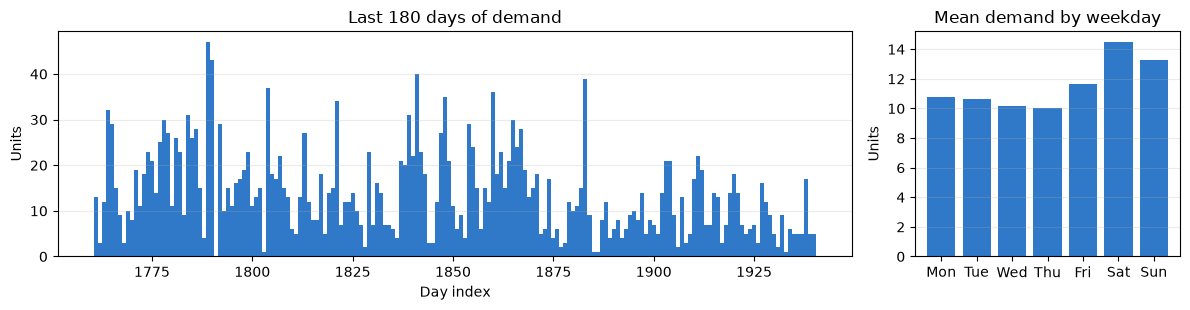

### Bundled scenarios available

,scenario_id,title,domain,days
0,walmart_pantry_m5,"Walmart · pantry SKU (steady, ~12/day)",retail_chain,1941
1,walmart_grocery_m5,Walmart · high-volume grocery (~131/day),retail_chain,1941
2,walmart_hobbies_sparse_m5,Walmart · hobbies (very sparse),retail_chain,1941
3,favorita_beverage_quito,Favorita Quito · top beverage (~500/day),retail_chain,1687
4,favorita_bread_quito,"Favorita Quito · bread (perishable, ~85/day)",retail_chain,1687
5,retail_online_uk,UK e-commerce · gift item (heavy-tailed),ecommerce,739


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from app.data import load_scenario, load_scenario_summaries

WEEKDAY_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

if UPLOADED_HISTORY is not None:
    history = np.asarray(UPLOADED_HISTORY, dtype=np.int64)
    if UPLOADED_WEEKDAY is not None:
        weekday = np.asarray(UPLOADED_WEEKDAY, dtype=np.int64)
    else:
        weekday = np.arange(history.size, dtype=np.int64) % 7
    scenario_title = "Uploaded demand"
    scenario_description = "Custom history provided in the parameters cell."
    scenario_costs_from_bundle: dict | None = None
    scenario_lead_time_from_bundle: dict | None = None
else:
    bundle = load_scenario(SCENARIO_ID)
    history = np.asarray(bundle.demand_history, dtype=np.int64)
    weekday = np.asarray(bundle.weekday, dtype=np.int64)
    scenario_title = bundle.summary.title
    scenario_description = bundle.summary.description
    scenario_costs_from_bundle = dict(bundle.costs)
    scenario_lead_time_from_bundle = dict(bundle.lead_time)

display(Markdown(
    f"**Scenario:** {scenario_title}\n\n"
    f"{scenario_description}\n\n"
    f"History: **{history.size} days**, mean **{history.mean():.2f} units/day**, "
    f"std **{history.std():.2f}**, max **{int(history.max())}**, "
    f"zero-days **{(history == 0).mean() * 100:.0f}%**."
))

recent = min(history.size, 180)
fig, (ax_hist, ax_weekday) = plt.subplots(
    1, 2, figsize=(12, 3.2),
    gridspec_kw={"width_ratios": [3, 1]},
)
ax_hist.bar(
    np.arange(history.size - recent, history.size),
    history[-recent:],
    width=1.0,
    color="#2f79c8",
)
ax_hist.set_title(f"Last {recent} days of demand")
ax_hist.set_xlabel("Day index")
ax_hist.set_ylabel("Units")
ax_hist.grid(axis="y", alpha=0.25)

weekday_means = [history[weekday == w].mean() if (weekday == w).any() else 0.0 for w in range(7)]
ax_weekday.bar(WEEKDAY_LABELS, weekday_means, color="#2f79c8")
ax_weekday.set_title("Mean demand by weekday")
ax_weekday.set_ylabel("Units")
ax_weekday.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

available_scenarios = load_scenario_summaries()
display(Markdown("### Bundled scenarios available"))
display(pd.DataFrame(
    [
        {"scenario_id": s.scenario_id, "title": s.title, "domain": s.domain, "days": s.history_days}
        for s in available_scenarios
    ]
))

## 3. Lead-time distribution preview

Draw 5,000 samples from the configured lead-time model and plot the histogram with mean and
p95 marks. This is the analog of the `LeadTimeDistributionChart` on the web app's Setup page,
but using the backend's actual `LeadTimeSampler`, so what you see here is exactly what the
optimizer will use.

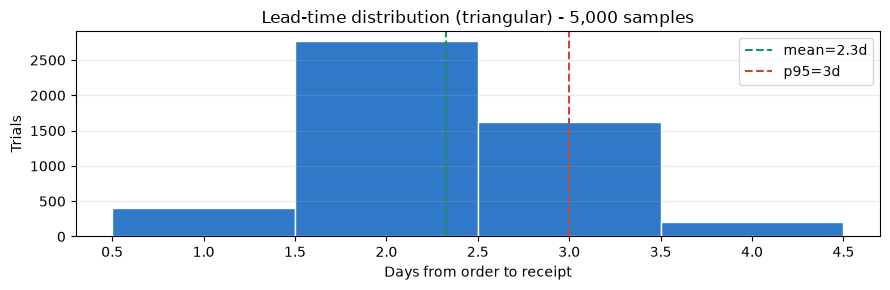

Sampler-reported mean: **2.33 days**, 95th percentile: **3.5 days**.

In [4]:
from app.domain import build_lead_time_sampler

lt_kwargs = {k: v for k, v in LEAD_TIME.items() if k != "distribution" and v is not None}
lead_time_sampler = build_lead_time_sampler(LEAD_TIME["distribution"], **lt_kwargs)

lt_preview_rng = np.random.default_rng(RANDOM_SEED)
lt_samples = lead_time_sampler.sample(5000, 1, lt_preview_rng).ravel()

fig, ax = plt.subplots(figsize=(9, 3.0))
lo, hi = int(lt_samples.min()), int(lt_samples.max())
bins = np.arange(lo, hi + 2) - 0.5
ax.hist(lt_samples, bins=bins, color="#2f79c8", edgecolor="white")
ax.axvline(lt_samples.mean(), color="#1f8f57", linestyle="--", label=f"mean={lt_samples.mean():.1f}d")
ax.axvline(np.quantile(lt_samples, 0.95), color="#c94a2f", linestyle="--", label=f"p95={np.quantile(lt_samples, 0.95):.0f}d")
ax.set_title(f"Lead-time distribution ({LEAD_TIME['distribution']}) - 5,000 samples")
ax.set_xlabel("Days from order to receipt")
ax.set_ylabel("Trials")
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

display(Markdown(
    f"Sampler-reported mean: **{lead_time_sampler.mean_days():.2f} days**, "
    f"95th percentile: **{lead_time_sampler.high_quantile_days(0.95):.1f} days**."
))

## 4. Cost inputs preview

Show the effective cost settings (either the scenario defaults or your override) and the
dollar impact of each action the optimizer trades off against.

### Effective cost inputs

,value
unit_cost,0.5400
holding_cost_per_unit_per_day,0.0004
stockout_cost_per_unit,0.9800
fixed_order_cost,30.0000
variable_order_cost_per_unit,0.0400
starting_inventory,81.0000
review_period_days,1.0000


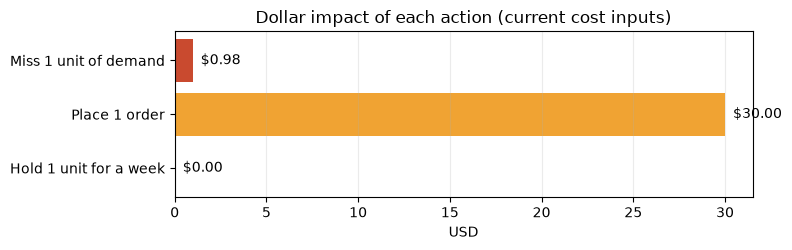

In [5]:
if COSTS_OVERRIDE is not None:
    effective_costs = dict(COSTS_OVERRIDE)
elif scenario_costs_from_bundle is not None:
    effective_costs = dict(scenario_costs_from_bundle)
else:
    effective_costs = {
        "unit_cost": 10.0,
        "holding_cost_per_unit_per_day": 0.05,
        "stockout_cost_per_unit": 8.0,
        "fixed_order_cost": 5.0,
        "variable_order_cost_per_unit": 0.0,
        "starting_inventory": 20.0,
        "review_period_days": 1,
    }

display(Markdown("### Effective cost inputs"))
display(pd.DataFrame({"value": effective_costs}))

impact = {
    "Hold 1 unit for a week": effective_costs["holding_cost_per_unit_per_day"] * 7,
    "Place 1 order": effective_costs["fixed_order_cost"],
    "Miss 1 unit of demand": effective_costs["stockout_cost_per_unit"],
}
fig, ax = plt.subplots(figsize=(8, 2.6))
labels = list(impact.keys())
values = list(impact.values())
bars = ax.barh(labels, values, color=["#2f79c8", "#f0a333", "#c94a2f"])
ax.set_title("Dollar impact of each action (current cost inputs)")
ax.set_xlabel("USD")
ax.grid(axis="x", alpha=0.25)
for bar, value in zip(bars, values, strict=True):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f"  ${value:,.2f}", va="center")
plt.tight_layout()
plt.show()

## 5. Run the optimizer end-to-end

Builds an `OptimizeRequest` from the parameters and calls `run_optimization`, the same
entry point the FastAPI `/api/optimize` route uses. Prints wall time so you can see how
Monte Carlo cost scales with `N_SIMULATIONS` and `HORIZON_DAYS`.

In [6]:
import time

from app.api.services import run_optimization
from app.schemas.optimize import CostAssumptions, LeadTimeModel, OptimizeRequest

request = OptimizeRequest(
    scenario_id=None if UPLOADED_HISTORY is not None else SCENARIO_ID,
    uploaded_history=UPLOADED_HISTORY,
    uploaded_weekday=UPLOADED_WEEKDAY,
    policy_family=POLICY_FAMILY,
    demand_model=DEMAND_MODEL,
    lead_time_model=LeadTimeModel(**LEAD_TIME),
    mode=MODE,
    target_service_level=TARGET_SERVICE_LEVEL if MODE == "service_level" else None,
    max_stockout_risk=MAX_STOCKOUT_RISK if MODE == "stockout_risk" else None,
    cvar_stockout_budget=CVAR_STOCKOUT_BUDGET if MODE == "cvar_budget" else None,
    costs=CostAssumptions(**COSTS_OVERRIDE) if COSTS_OVERRIDE is not None else None,
    n_simulations=N_SIMULATIONS,
    horizon_days=HORIZON_DAYS,
    random_seed=RANDOM_SEED,
)

started = time.perf_counter()
response = run_optimization(request)
elapsed_s = time.perf_counter() - started
display(Markdown(
    f"Computed in **{elapsed_s:.2f}s** - "
    f"{response.metrics.n_sims:,} simulations × {response.metrics.horizon_days} days × "
    f"{len(response.frontier)} candidate policies on the frontier."
))

Computed in **10.40s** - 2,000 simulations × 180 days × 50 candidate policies on the frontier.

## 6. Recommended policy and explanation

The chosen `(r, S)` or `(r, Q)` values, its expected metrics, and the narrative shown to
end-users on the web app's "Why this policy?" panel.

In [7]:
policy = response.recommended_policy
metrics = response.metrics
explanation = response.explanation

if policy.policy_family == "r_Q":
    policy_str = f"r = {policy.reorder_point}, Q = {policy.order_quantity}"
else:
    policy_str = f"r = {policy.reorder_point}, S = {policy.order_up_to}"

display(Markdown(f"### Recommended policy: {policy_str}"))

metric_rows = pd.DataFrame([
    {"metric": "Expected total cost", "value": f"${metrics.expected_total_cost:,.2f}"},
    {"metric": "Cycle service level", "value": f"{metrics.cycle_service_level * 100:.1f}%"},
    {"metric": "Fill rate", "value": f"{metrics.fill_rate * 100:.1f}%"},
    {"metric": "Stockout probability", "value": f"{metrics.stockout_probability * 100:.1f}%"},
    {"metric": "Average on-hand", "value": f"{metrics.average_on_hand:.1f}"},
    {"metric": "Orders/month", "value": f"{metrics.average_orders_per_month:.2f}"},
    {"metric": "Expected stockout cost", "value": f"${metrics.expected_stockout_cost:,.2f}"},
    {"metric": "Expected holding cost", "value": f"${metrics.expected_holding_cost:,.2f}"},
    {"metric": "Expected ordering cost", "value": f"${metrics.expected_ordering_cost:,.2f}"},
    {"metric": "CVaR stockout cost (95%)", "value": f"${metrics.cvar_stockout_cost:,.2f}"},
])
display(metric_rows)

display(Markdown(
    f"**Why this policy** (dominant driver: `{explanation.dominant_cost_driver}`)\n\n"
    f"> {explanation.narrative}\n\n"
    f"- Expected lead-time demand: **{explanation.expected_lead_time_demand:.1f}** units\n"
    f"- Implied safety stock: **{explanation.safety_stock}** units"
))

### Recommended policy - r = 91, S = 496

,metric,value
0,Expected total cost,$277.66
1,Cycle service level,96.5%
2,Fill rate,100.0%
3,Stockout probability,3.5%
4,Average on-hand,276.0
5,Orders/month,0.92
6,Expected stockout cost,$0.43
7,Expected holding cost,$19.87
8,Expected ordering cost,$257.36
9,CVaR stockout cost (95%),$8.57


**Why this policy** (dominant driver: `ordering`)

> The selected reorder point is 91 units. Average demand during lead time is 26.5 units, so 64 units are held as safety stock and orders up to 496 units. Expected monthly cost is $277.66 with a fill rate of 100.0% and a stockout probability of 3.5%. The dominant cost driver is ordering.

- Expected lead-time demand: **26.5** units
- Implied safety stock: **64** units

## 7. Cost vs reliability frontier

Every candidate policy plotted by expected cost and cycle service level. The green diamond
is the recommendation, orange triangles are named reference policies, the dashed line is
the efficient frontier (min cost for each attainable service level).

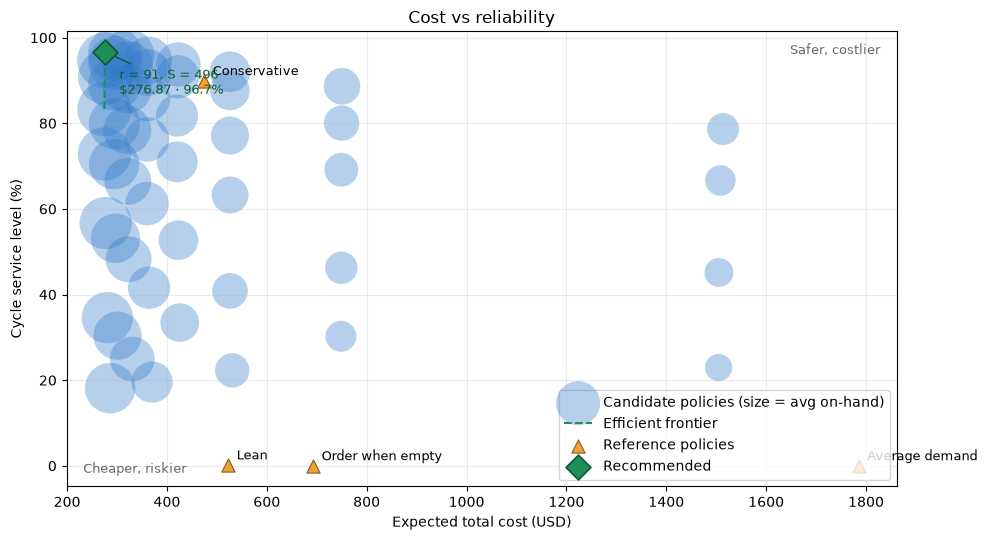

In [8]:
frontier_df = pd.DataFrame([
    {
        "cost": p.expected_total_cost,
        "service_level": p.cycle_service_level,
        "average_on_hand": p.average_on_hand,
        "is_recommended": p.is_recommended,
    }
    for p in response.frontier
])

pareto = (
    frontier_df.sort_values("cost")
    .assign(cum_max_service=lambda d: d["service_level"].cummax())
    .query("service_level == cum_max_service")
)

reference_rows = []
for ref in response.comparison_policies:
    reference_rows.append({
        "label": ref.label.replace("_", " ").capitalize(),
        "cost": ref.metrics.expected_total_cost,
        "service_level": ref.metrics.cycle_service_level,
        "average_on_hand": ref.metrics.average_on_hand,
    })
reference_df = pd.DataFrame(reference_rows)

fig, ax = plt.subplots(figsize=(10, 5.5))
non_reco = frontier_df[~frontier_df["is_recommended"]]
ax.scatter(
    non_reco["cost"],
    non_reco["service_level"] * 100,
    s=(non_reco["average_on_hand"] * 6 + 20),
    color="#2f79c8",
    alpha=0.35,
    edgecolor="none",
    label="Candidate policies (size = avg on-hand)",
)

ax.plot(
    pareto["cost"],
    pareto["service_level"] * 100,
    color="#1f8f57",
    linestyle="--",
    linewidth=1.5,
    label="Efficient frontier",
)

if not reference_df.empty:
    ax.scatter(
        reference_df["cost"],
        reference_df["service_level"] * 100,
        marker="^",
        s=90,
        color="#f0a333",
        edgecolor="#8a5a1a",
        linewidth=0.8,
        label="Reference policies",
        zorder=3,
    )
    for _, row in reference_df.iterrows():
        ax.annotate(
            row["label"],
            xy=(row["cost"], row["service_level"] * 100),
            xytext=(6, 4),
            textcoords="offset points",
            fontsize=9,
        )

reco_row = frontier_df[frontier_df["is_recommended"]].iloc[0]
ax.scatter(
    reco_row["cost"],
    reco_row["service_level"] * 100,
    marker="D",
    s=160,
    color="#1f8f57",
    edgecolor="#0f5a34",
    linewidth=1.2,
    label="Recommended",
    zorder=4,
)
ax.annotate(
    f"{policy_str}\n${reco_row['cost']:.2f} · {reco_row['service_level'] * 100:.1f}%",
    xy=(reco_row["cost"], reco_row["service_level"] * 100),
    xytext=(10, -30),
    textcoords="offset points",
    fontsize=9,
    color="#0f5a34",
    arrowprops={"arrowstyle": "->", "color": "#0f5a34"},
)

ax.set_xlabel("Expected total cost (USD)")
ax.set_ylabel("Cycle service level (%)")
ax.set_title("Cost vs reliability")
ax.grid(alpha=0.25)
ax.legend(loc="lower right")

xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
ax.text(xmin + (xmax - xmin) * 0.02, ymin + (ymax - ymin) * 0.03,
        "Cheaper, riskier", color="#666", fontsize=9)
ax.text(xmax - (xmax - xmin) * 0.02, ymax - (ymax - ymin) * 0.05,
        "Safer, costlier", color="#666", fontsize=9, ha="right")

plt.tight_layout()
plt.show()

## 8. Inventory fan chart under the recommended policy

Aggregates the representative simulation paths returned by the optimizer into a fan chart
of on-hand inventory over time. The shaded bands are the 5–95% and 25–75% percentile ranges
across simulations, the dark line is the median. Orange diamonds mark days a replenishment
was placed on the median trace; green circles mark days a shipment arrived.

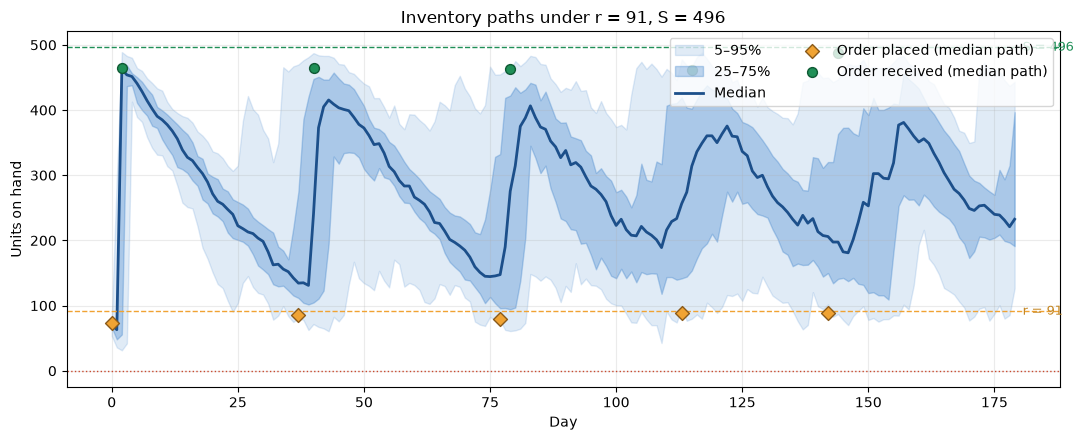

Across every simulated day and trajectory, on-hand dropped to or below zero **0.0%** of the time.

In [9]:
paths = response.simulation.paths
horizon = response.simulation.horizon_days

on_hand_matrix = np.array([p.on_hand for p in paths], dtype=float)
p5 = np.percentile(on_hand_matrix, 5, axis=0)
p25 = np.percentile(on_hand_matrix, 25, axis=0)
p50 = np.percentile(on_hand_matrix, 50, axis=0)
p75 = np.percentile(on_hand_matrix, 75, axis=0)
p95 = np.percentile(on_hand_matrix, 95, axis=0)

median_idx = int(np.argsort([abs(p.percentile - 50) for p in paths])[0])
median_path = paths[median_idx]
days_placed = [d for d, v in enumerate(median_path.orders_placed) if v > 0]
days_received = [d for d, v in enumerate(median_path.receipts) if v > 0]

fig, ax = plt.subplots(figsize=(11, 4.5))
days = np.arange(horizon)
ax.fill_between(days, p5, p95, color="#2f79c8", alpha=0.15, label="5–95%")
ax.fill_between(days, p25, p75, color="#2f79c8", alpha=0.3, label="25–75%")
ax.plot(days, p50, color="#1c4f8a", linewidth=2, label="Median")

if policy.order_up_to is not None:
    ax.axhline(policy.order_up_to, color="#1f8f57", linestyle="--", linewidth=1)
    ax.text(horizon - 1, policy.order_up_to, f"  S = {policy.order_up_to}",
            va="center", color="#1f8f57", fontsize=9)
ax.axhline(policy.reorder_point, color="#f0a333", linestyle="--", linewidth=1)
ax.text(horizon - 1, policy.reorder_point, f"  r = {policy.reorder_point}",
        va="center", color="#c48520", fontsize=9)
ax.axhline(0, color="#c94a2f", linestyle=":", linewidth=1)

if days_placed:
    ax.scatter(days_placed, np.array(median_path.on_hand)[days_placed],
               marker="D", color="#f0a333", edgecolor="#8a5a1a", zorder=3,
               s=50, label="Order placed (median path)")
if days_received:
    ax.scatter(days_received, np.array(median_path.on_hand)[days_received],
               marker="o", color="#1f8f57", edgecolor="#0f5a34", zorder=3,
               s=50, label="Order received (median path)")

ax.set_xlabel("Day")
ax.set_ylabel("Units on hand")
ax.set_title(f"Inventory paths under {policy_str}")
ax.grid(alpha=0.25)
ax.legend(loc="upper right", ncols=2)
plt.tight_layout()
plt.show()

stockout_day_fraction = float((on_hand_matrix <= 0).mean())
display(Markdown(
    f"Across every simulated day and trajectory, on-hand dropped to or below zero "
    f"**{stockout_day_fraction * 100:.1f}%** of the time."
))

## 9. Alternatives comparison

Reference policies simulated on the same demand and lead-time draws, with deltas versus the
recommendation. Green = beats the recommendation on that metric, red = loses.

In [ ]:
def _policy_str(p) -> str:
    if p.policy_family == "r_Q":
        return f"r={p.reorder_point}, Q={p.order_quantity}"
    return f"r={p.reorder_point}, S={p.order_up_to}"

rows = [
    {
        "label": "Recommended",
        "policy": _policy_str(policy),
        "cost": metrics.expected_total_cost,
        "service_level": metrics.cycle_service_level,
        "stockout_prob": metrics.stockout_probability,
        "avg_on_hand": metrics.average_on_hand,
        "cost_delta": 0.0,
        "service_delta": 0.0,
        "stockout_delta": 0.0,
        "inventory_delta": 0.0,
        "is_picked": True,
    }
]
for c in response.comparison_policies:
    rows.append({
        "label": c.label.replace("_", " ").capitalize(),
        "policy": _policy_str(c.policy),
        "cost": c.metrics.expected_total_cost,
        "service_level": c.metrics.cycle_service_level,
        "stockout_prob": c.metrics.stockout_probability,
        "avg_on_hand": c.metrics.average_on_hand,
        "cost_delta": c.cost_delta,
        "service_delta": c.service_level_delta,
        "stockout_delta": c.stockout_probability_delta,
        "inventory_delta": c.average_on_hand_delta,
        "is_picked": False,
    })
comparison_df = pd.DataFrame(rows)

def _fmt_delta(value: float, kind: str, better: str) -> str:
    if abs(value) < 1e-6:
        return "-"
    prefix = "+" if value > 0 else ""
    if kind == "currency":
        return f"{prefix}${value:,.2f}"
    if kind == "percent":
        return f"{prefix}{value * 100:.1f}%"
    return f"{prefix}{value:.1f}"

def _better(value: float, better: str) -> bool:
    if abs(value) < 1e-6:
        return None
    if better == "lower":
        return value < 0
    return value > 0

DELTA_META = [
    ("cost_delta", "currency", "lower"),
    ("service_delta", "percent", "higher"),
    ("stockout_delta", "percent", "lower"),
    ("inventory_delta", "count", "lower"),
]

def style_row(row: pd.Series):
    styles = []
    for col in comparison_df.columns:
        style = ""
        if row["is_picked"]:
            style = "background-color: rgba(31, 143, 87, 0.08); font-weight: 600;"
        for delta_col, _, better in DELTA_META:
            if col == delta_col and not row["is_picked"]:
                is_better = _better(row[delta_col], better)
                if is_better is True:
                    style = "color: #1f8f57;"
                elif is_better is False:
                    style = "color: #c94a2f;"
        styles.append(style)
    return styles

display_df = comparison_df.copy()
display_df["cost"] = display_df["cost"].map(lambda v: f"${v:,.2f}")
display_df["service_level"] = display_df["service_level"].map(lambda v: f"{v * 100:.1f}%")
display_df["stockout_prob"] = display_df["stockout_prob"].map(lambda v: f"{v * 100:.1f}%")
display_df["avg_on_hand"] = display_df["avg_on_hand"].map(lambda v: f"{v:.1f}")
display_df["cost_delta"] = comparison_df["cost_delta"].map(lambda v: _fmt_delta(v, "currency", "lower"))
display_df["service_delta"] = comparison_df["service_delta"].map(lambda v: _fmt_delta(v, "percent", "higher"))
display_df["stockout_delta"] = comparison_df["stockout_delta"].map(lambda v: _fmt_delta(v, "percent", "lower"))
display_df["inventory_delta"] = comparison_df["inventory_delta"].map(lambda v: _fmt_delta(v, "count", "lower"))

display_df = display_df[
    ["label", "policy", "cost", "cost_delta", "service_level", "service_delta",
     "stockout_prob", "stockout_delta", "avg_on_hand", "inventory_delta", "is_picked"]
]
display_df.columns = [
    "Label", "Policy", "Cost", "Δ cost", "Service level", "Δ SL",
    "Stockout prob.", "Δ stockout", "Avg on-hand", "Δ on-hand", "is_picked",
]

try:
    styled = comparison_df.style.apply(style_row, axis=1)
    display(styled)
except (ImportError, AttributeError) as exc:
    print(f"(Skipping styled comparison: {exc})")
    display(comparison_df)

display(Markdown("### Human-readable comparison"))
display(display_df.drop(columns=["is_picked"]))

,label,policy,cost,service_level,stockout_prob,avg_on_hand,cost_delta,service_delta,stockout_delta,inventory_delta,is_picked
0,Recommended,"r=91, S=496",277.660703,0.964500,0.035500,275.990881,0.000000,0.000000,0.000000,0.000000,True
1,Lean,"r=27, S=189",523.091997,0.002000,0.998000,88.903428,-245.431293,0.962500,-0.962500,187.087453,False
2,Conservative,"r=86, S=248",475.004296,0.899500,0.100500,145.515217,-197.343592,0.065000,-0.065000,130.475664,False
3,Order when empty,"r=0, S=162",693.047074,0.000000,1.000000,68.813667,-415.386371,0.964500,-0.964500,207.177214,False
4,Average demand,"r=27, S=54",1785.694969,0.000000,1.000000,22.560536,-1508.034265,0.964500,-0.964500,253.430344,False


### Human-readable comparison

,Label,Policy,Cost,Δ cost,Service level,Δ SL,Stockout prob.,Δ stockout,Avg on-hand,Δ on-hand
0,Recommended,"r=91, S=496",$277.66,-,96.5%,-,3.5%,-,276.0,-
1,Lean,"r=27, S=189",$523.09,$-245.43,0.2%,+96.2%,99.8%,-96.2%,88.9,+187.1
2,Conservative,"r=86, S=248",$475.00,$-197.34,90.0%,+6.5%,10.1%,-6.5%,145.5,+130.5
3,Order when empty,"r=0, S=162",$693.05,$-415.39,0.0%,+96.5%,100.0%,-96.5%,68.8,+207.2
4,Average demand,"r=27, S=54","$1,785.69","$-1,508.03",0.0%,+96.5%,100.0%,-96.5%,22.6,+253.4


## 10. Where to go from here

- Change `SCENARIO_ID` at the top and rerun to compare the shape of stochastic inventory
  problems across household vs small-business framings.
- Set `MODE = "stockout_risk"` with `MAX_STOCKOUT_RISK = 0.02` to see how the frontier
  slides when you constrain worst-case risk instead of average service level.
- Feed your own history via `UPLOADED_HISTORY = [...]` (14 or more daily observations); no
  scenario file needed.
- The full raw response object is bound to `response`, so you can inspect any field
  (`response.frontier`, `response.simulation.paths`, `response.metrics`) directly if you
  want to slice further.